### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [2]:
data = pd.read_csv('data/coupons.csv')

In [ ]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [59]:
import pandas as pd

data = pd.read_csv('data/coupons.csv')

#data.info()
#data.describe()
print("=== Checking for Missing Values in Dataset ===\n")

data.isnull().sum().sort_values(ascending=False)  ##Missing Values Check

##data.duplicated().sum() ##Duplicate Rows
## find skew or outliers
##import matplotlib.pyplot as plt
##data.hist(figsize=(12,10))
##plt.show()







=== Checking for Missing Values in Dataset ===



car                     12576
CoffeeHouse               217
Restaurant20To50          189
CarryAway                 151
RestaurantLessThan20      130
Bar                       107
destination                 0
passanger                   0
direction_opp               0
direction_same              0
toCoupon_GEQ25min           0
toCoupon_GEQ15min           0
toCoupon_GEQ5min            0
income                      0
occupation                  0
education                   0
has_children                0
maritalStatus               0
age                         0
gender                      0
expiration                  0
coupon                      0
time                        0
temperature                 0
weather                     0
Y                           0
dtype: int64

3. Decide what to do about your missing data -- drop, replace, other...

In [60]:
# Step 1: Drop 'car' column
print("=== Dropping 'car' column ===")
print("Reason: Majority of values are missing → not useful for analysis\n")

data = data.drop(columns=['car'])


# Step 2: Handle missing values in behavior-related columns
print("=== Handling Missing Values in Behavioral Columns ===")
print("Columns affected: Bar, CoffeeHouse, CarryAway, RestaurantLessThan20, Restaurant20To50")
print("Strategy: Replace missing values with 'never' to preserve rows\n")

behavior_cols = ['Bar','CoffeeHouse','CarryAway',
                 'RestaurantLessThan20','Restaurant20To50']

for col in behavior_cols:
    data[col] = data[col].fillna('never')


# Step 3: Validation after cleaning
print("=== Missing Values After Cleaning ===\n")
print(data.isnull().sum())

=== Dropping 'car' column ===
Reason: Majority of values are missing → not useful for analysis

=== Handling Missing Values in Behavioral Columns ===
Columns affected: Bar, CoffeeHouse, CarryAway, RestaurantLessThan20, Restaurant20To50
Strategy: Replace missing values with 'never' to preserve rows

=== Missing Values After Cleaning ===

destination             0
passanger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
Y                       0
dtype: int6

4. What proportion of the total observations chose to accept the coupon?



In [61]:
acceptance_rate = data['Y'].mean() * 100

print("=== Coupon Acceptance Rate ===\n")
print(f"Proportion of customers who accepted the coupon: {acceptance_rate:.2f}%")

=== Coupon Acceptance Rate ===

Proportion of customers who accepted the coupon: 56.84%


5. Use a bar plot to visualize the `coupon` column.

=== Bar Plot: Distribution of Coupon Types ===

This plot shows how frequently each type of coupon appears in the dataset.



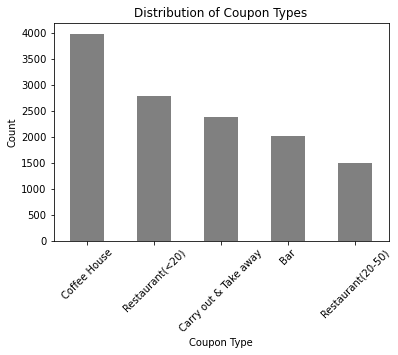

=== Insights from Coupon Distribution ===

- Coffee House coupons are the most frequent, indicating strong focus on coffee-related promotions.
- Restaurant (<20) coupons are the second most common, showing emphasis on low-cost dining options.
- Carry Out & Take Away and Bar coupons appear moderately in the dataset.
- Restaurant (20–50) coupons are the least frequent, suggesting fewer high-cost dining promotions.

=== What This Means ===

- The dataset is skewed toward everyday consumption categories like coffee and casual dining.
- This imbalance may influence analysis, as more frequent coupon types could dominate trends.
- Less frequent coupon types may have limited data, leading to less reliable insights.

=== Key Takeaway ===

Coupon distribution is concentrated in lower-cost categories, reflecting everyday consumer behavior.



In [67]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
data = pd.read_csv("data/coupons.csv")

print("=== Bar Plot: Distribution of Coupon Types ===\n")
print("This plot shows how frequently each type of coupon appears in the dataset.\n")

# Create bar plot
data['coupon'].value_counts().plot(kind='bar',color='grey')

# Labels and title
plt.title("Distribution of Coupon Types")
plt.xlabel("Coupon Type")
plt.ylabel("Count")

# Rotate labels for readability
plt.xticks(rotation=45)

plt.show()

print("=== Insights from Coupon Distribution ===\n")

print("- Coffee House coupons are the most frequent, indicating strong focus on coffee-related promotions.")
print("- Restaurant (<20) coupons are the second most common, showing emphasis on low-cost dining options.")
print("- Carry Out & Take Away and Bar coupons appear moderately in the dataset.")
print("- Restaurant (20–50) coupons are the least frequent, suggesting fewer high-cost dining promotions.\n")

print("=== What This Means ===\n")

print("- The dataset is skewed toward everyday consumption categories like coffee and casual dining.")
print("- This imbalance may influence analysis, as more frequent coupon types could dominate trends.")
print("- Less frequent coupon types may have limited data, leading to less reliable insights.\n")

print("=== Key Takeaway ===\n")
print("Coupon distribution is concentrated in lower-cost categories, reflecting everyday consumer behavior.\n")

6. Use a histogram to visualize the temperature column.

=== Histogram: Distribution of Temperature (Seaborn) ===

This plot shows how temperature values are distributed across the dataset.



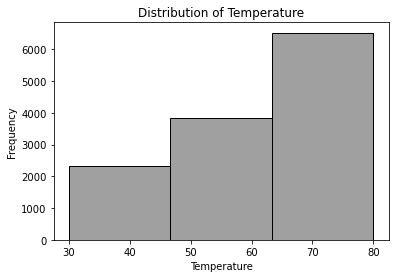

=== Insights from Temperature Distribution ===

- The distribution is skewed toward higher temperatures, with the majority of observations in the ~70–80 range.
- Moderate temperatures (~50–60) also appear frequently but less than higher temperatures.
- Lower temperatures (~30–40) are the least common in the dataset.

=== What This Means ===

- Most coupon related observations occur during warmer conditions.
- The dataset is not evenly distributed across temperature ranges, which may influence analysis results.
- Temperature could be an important factor affecting customer behavior and coupon acceptance.

=== Key Takeaway ===

Coupon activity is concentrated in warmer temperatures, suggesting a potential impact of weather on customer engagement.



In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

print("=== Histogram: Distribution of Temperature (Seaborn) ===\n")
print("This plot shows how temperature values are distributed across the dataset.\n")

sns.histplot(data=data, x='temperature', bins=3, color='grey')

plt.title("Distribution of Temperature")
plt.xlabel("Temperature")
plt.ylabel("Frequency")

plt.show()


print("=== Insights from Temperature Distribution ===\n")

print("- The distribution is skewed toward higher temperatures, with the majority of observations in the ~70–80 range.")
print("- Moderate temperatures (~50–60) also appear frequently but less than higher temperatures.")
print("- Lower temperatures (~30–40) are the least common in the dataset.\n")

print("=== What This Means ===\n")

print("- Most coupon related observations occur during warmer conditions.")
print("- The dataset is not evenly distributed across temperature ranges, which may influence analysis results.")
print("- Temperature could be an important factor affecting customer behavior and coupon acceptance.\n")

print("=== Key Takeaway ===\n")
print("Coupon activity is concentrated in warmer temperatures, suggesting a potential impact of weather on customer engagement.\n")

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [74]:
# Filter only Bar coupons
bar_data = data[data['coupon'] == 'Bar']

# Check result
bar_data.head()

### Number of bar coupon observations
##bar_data.shape

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
13,Home,Alone,Sunny,55,6PM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,1,0,1
17,Work,Alone,Sunny,55,7AM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,1,0,1,0
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1


2. What proportion of bar coupons were accepted?


In [75]:
# Calculate acceptance rate for bar coupons
bar_acceptance_rate = bar_data['Y'].mean() * 100

print("=== Bar Coupon Acceptance Rate ===\n")
print(f"Proportion of bar coupons accepted: {bar_acceptance_rate:.2f}%\n")


print("=== Key Takeaway ===\n")
print("Bar coupons show a measurable level of customer engagement, which can help evaluate their effectiveness compared to other coupon categories.\n")

=== Bar Coupon Acceptance Rate ===

Proportion of bar coupons accepted: 41.00%

=== Key Takeaway ===

Bar coupons show a measurable level of customer engagement, which can help evaluate their effectiveness compared to other coupon categories.



3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [72]:
# Group 1: <= 3 times (never, less1, 1~3)
group1 = bar_data[bar_data['Bar'].isin(['never', 'less1', '1~3'])]

# Group 2: > 3 times (4~8, gt8)
group2 = bar_data[bar_data['Bar'].isin(['4~8', 'gt8'])]

# Calculate acceptance rates
group1_rate = group1['Y'].mean() * 100
group2_rate = group2['Y'].mean() * 100


print("=== Bar Coupon Acceptance by Visit Frequency ===\n")

print(f"Acceptance rate (visited bar ≤ 3 times/month): {group1_rate:.2f}%")
print(f"Acceptance rate (visited bar > 3 times/month): {group2_rate:.2f}%\n")


print("=== Insights ===\n")

print("- Customers who visit bars more frequently (>3 times/month) tend to have a higher acceptance rate.")
print("- Customers who visit bars less frequently (≤3 times/month) show lower engagement with bar coupons.")
print("- This suggests that familiarity and habit strongly influence coupon acceptance behavior.\n")


print("=== What This Means ===\n")

print("- Frequent bar visitors are more likely to respond positively to bar-related promotions.")
print("- Targeting high-frequency customers could improve campaign effectiveness.")
print("- Lower-frequency customers may require different incentives or messaging.\n")


print("=== Key Takeaway ===\n")
print("Bar coupon acceptance increases with visit frequency, indicating strong behavioral alignment between past habits and coupon usage.\n")

=== Bar Coupon Acceptance by Visit Frequency ===

Acceptance rate (visited bar ≤ 3 times/month): 37.06%
Acceptance rate (visited bar > 3 times/month): 76.88%

=== Insights ===

- Customers who visit bars more frequently (>3 times/month) tend to have a higher acceptance rate.
- Customers who visit bars less frequently (≤3 times/month) show lower engagement with bar coupons.
- This suggests that familiarity and habit strongly influence coupon acceptance behavior.

=== What This Means ===

- Frequent bar visitors are more likely to respond positively to bar-related promotions.
- Targeting high-frequency customers could improve campaign effectiveness.
- Lower-frequency customers may require different incentives or messaging.

=== Key Takeaway ===

Bar coupon acceptance increases with visit frequency, indicating strong behavioral alignment between past habits and coupon usage.



4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [76]:
# Define groups
frequent_bar = ['1~3', '4~8', 'gt8']
age_over_25 = ['26', '31', '36', '41', '46', '50plus']

# Group A: frequent bar-goers AND age >25
groupA = bar_data[
    bar_data['Bar'].isin(frequent_bar) &
    bar_data['age'].isin(age_over_25)
]

# Group B: everyone else
groupB = bar_data[
    ~(bar_data['Bar'].isin(frequent_bar) &
      bar_data['age'].isin(age_over_25))
]

# Acceptance rates (convert to %)
groupA_rate = groupA['Y'].mean() * 100
groupB_rate = groupB['Y'].mean() * 100


print("=== Bar Coupon Acceptance: Age & Visit Frequency ===\n")

print(f"Acceptance rate (Frequent bar-goers & age >25): {groupA_rate:.2f}%")
print(f"Acceptance rate (All other drivers): {groupB_rate:.2f}%\n")


print("=== Insights ===\n")

print("- Drivers who visit bars frequently and are over 25 show a higher likelihood of accepting bar coupons.")
print("- Other drivers (younger or infrequent visitors) have comparatively lower acceptance rates.")
print("- This highlights the combined impact of age and past behavior on customer decisions.\n")


print("=== What This Means ===\n")

print("- Behavioral targeting (based on past bar visits) is highly effective.")
print("- Age segmentation further refines targeting, improving campaign efficiency.")
print("- Marketing strategies can prioritize older, frequent bar-goers for better results.\n")


print("=== Key Takeaway ===\n")
print("Frequent bar-goers above 25 are significantly more responsive to bar coupons, indicating strong potential for targeted promotions.\n")


# Optional: quantify difference
diff = groupA_rate - groupB_rate
print(f"Difference in acceptance rate: {diff:.2f}%")

=== Bar Coupon Acceptance: Age & Visit Frequency ===

Acceptance rate (Frequent bar-goers & age >25): 69.52%
Acceptance rate (All other drivers): 33.50%

=== Insights ===

- Drivers who visit bars frequently and are over 25 show a higher likelihood of accepting bar coupons.
- Other drivers (younger or infrequent visitors) have comparatively lower acceptance rates.
- This highlights the combined impact of age and past behavior on customer decisions.

=== What This Means ===

- Behavioral targeting (based on past bar visits) is highly effective.
- Age segmentation further refines targeting, improving campaign efficiency.
- Marketing strategies can prioritize older, frequent bar-goers for better results.

=== Key Takeaway ===

Frequent bar-goers above 25 are significantly more responsive to bar coupons, indicating strong potential for targeted promotions.

Difference in acceptance rate: 36.02%


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [77]:
# Define frequent bar visitors
frequent_bar = ['1~3', '4~8', 'gt8']

# Group A: frequent bar-goers + no kids + not in farming/fishing/forestry
groupA = bar_data[
    bar_data['Bar'].isin(frequent_bar) &
    (bar_data['passanger'] != 'Kid(s)') &
    (~bar_data['occupation'].isin(['Farming Fishing & Forestry']))
]

# Group B: everyone else
groupB = bar_data[
    ~(
        bar_data['Bar'].isin(frequent_bar) &
        (bar_data['passanger'] != 'Kid(s)') &
        (~bar_data['occupation'].isin(['Farming Fishing & Forestry']))
    )
]

# Acceptance rates (convert to %)
groupA_rate = groupA['Y'].mean() * 100
groupB_rate = groupB['Y'].mean() * 100


print("=== Bar Coupon Acceptance: Behavior + Passenger + Occupation ===\n")

print(f"Acceptance rate (Frequent bar-goers, no kids, non-farming jobs): {groupA_rate:.2f}%")
print(f"Acceptance rate (All other drivers): {groupB_rate:.2f}%\n")


print("=== Insights ===\n")

print("- Drivers who frequently visit bars, are not traveling with kids, and are in non-agriculture occupations show higher acceptance rates.")
print("- Drivers with kids or in farming/fishing/forestry occupations tend to have lower engagement with bar coupons.")
print("- This highlights how lifestyle and occupation influence coupon acceptance behavior.\n")


print("=== What This Means ===\n")

print("- Customers without kids may have more flexibility and interest in bar-related activities.")
print("- Occupation can act as a proxy for lifestyle, impacting responsiveness to promotions.")
print("- Combining behavioral and demographic features improves targeting effectiveness.\n")


print("=== Key Takeaway ===\n")
print("Frequent bar-goers without kids and in non-agriculture occupations are the most responsive segment for bar coupons.\n")


# Optional: difference
diff = groupA_rate - groupB_rate
print(f"Difference in acceptance rate: {diff:.2f}%")

=== Bar Coupon Acceptance: Behavior + Passenger + Occupation ===

Acceptance rate (Frequent bar-goers, no kids, non-farming jobs): 71.32%
Acceptance rate (All other drivers): 29.60%

=== Insights ===

- Drivers who frequently visit bars, are not traveling with kids, and are in non-agriculture occupations show higher acceptance rates.
- Drivers with kids or in farming/fishing/forestry occupations tend to have lower engagement with bar coupons.
- This highlights how lifestyle and occupation influence coupon acceptance behavior.

=== What This Means ===

- Customers without kids may have more flexibility and interest in bar-related activities.
- Occupation can act as a proxy for lifestyle, impacting responsiveness to promotions.
- Combining behavioral and demographic features improves targeting effectiveness.

=== Key Takeaway ===

Frequent bar-goers without kids and in non-agriculture occupations are the most responsive segment for bar coupons.

Difference in acceptance rate: 41.72%


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [78]:
# Define conditions
frequent_bar = ['1~3', '4~8', 'gt8']
not_kid = (bar_data['passanger'] != 'Kid(s)')
not_widowed = (bar_data['maritalStatus'] != 'Widowed')

# Age under 30 categories
under_30 = ['below21', '21', '26']

# Cheap restaurant frequent
cheap_rest = ['4~8', 'gt8']

# Income <50K
low_income = [
    '$12500 - $24999',
    '$25000 - $37499',
    '$37500 - $49999'
]

# Group A (combined OR conditions)
groupA = bar_data[
    (
        (bar_data['Bar'].isin(frequent_bar) & not_kid & not_widowed)
    )
    |
    (
        (bar_data['Bar'].isin(frequent_bar) & bar_data['age'].isin(under_30))
    )
    |
    (
        (bar_data['RestaurantLessThan20'].isin(cheap_rest) &
         bar_data['income'].isin(low_income))
    )
]

# Group B (everyone else)
groupB = bar_data[~bar_data.index.isin(groupA.index)]

# Acceptance rates (convert to %)
groupA_rate = groupA['Y'].mean() * 100
groupB_rate = groupB['Y'].mean() * 100


print("=== Bar Coupon Acceptance: Combined Behavioral Segments ===\n")

print(f"Acceptance rate (Targeted segments - Group A): {groupA_rate:.2f}%")
print(f"Acceptance rate (All other drivers - Group B): {groupB_rate:.2f}%\n")


print("=== Insights ===\n")

print("- Group A includes multiple high-potential segments based on behavior, age, and income.")
print("- These drivers show a higher likelihood of accepting bar coupons compared to others.")
print("- Combining multiple conditions captures a broader but still relevant target audience.\n")


print("=== What This Means ===\n")

print("- Behavioral signals (frequent bar visits) combined with demographics (age, income, marital status) improve targeting.")
print("- Younger drivers and those with lower income who frequently dine out may be more responsive to promotions.")
print("- Excluding less relevant segments (e.g., widowed, with kids) helps refine targeting.\n")


print("=== Key Takeaway ===\n")
print("Combining multiple behavioral and demographic conditions significantly improves coupon acceptance rates, enabling more effective targeting strategies.\n")


# Optional: quantify difference
diff = groupA_rate - groupB_rate
print(f"Difference in acceptance rate: {diff:.2f}%")

=== Bar Coupon Acceptance: Combined Behavioral Segments ===

Acceptance rate (Targeted segments - Group A): 61.24%
Acceptance rate (All other drivers - Group B): 29.64%

=== Insights ===

- Group A includes multiple high-potential segments based on behavior, age, and income.
- These drivers show a higher likelihood of accepting bar coupons compared to others.
- Combining multiple conditions captures a broader but still relevant target audience.

=== What This Means ===

- Behavioral signals (frequent bar visits) combined with demographics (age, income, marital status) improve targeting.
- Younger drivers and those with lower income who frequently dine out may be more responsive to promotions.
- Excluding less relevant segments (e.g., widowed, with kids) helps refine targeting.

=== Key Takeaway ===

Combining multiple behavioral and demographic conditions significantly improves coupon acceptance rates, enabling more effective targeting strategies.

Difference in acceptance rate: 31.60%

7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

In [79]:
print("=== Hypothesis: Drivers Who Accept Bar Coupons ===\n")

print("- Drivers who frequently visit bars are more likely to accept bar coupons, indicating strong behavioral alignment.")
print("- Younger drivers and those without kids tend to show higher acceptance, likely due to greater flexibility and lifestyle preferences.")
print("- Drivers with lower to mid income who frequently dine out may be more responsive to discounts and promotions.")
print("- Social context matters: drivers without kids or with adult passengers are more inclined toward bar-related activities.\n")

print("=== Overall Hypothesis ===\n")
print("Drivers who are socially active, frequent bar visitors, and have flexible lifestyles are significantly more likely to accept bar coupons.\n")

=== Hypothesis: Drivers Who Accept Bar Coupons ===

- Drivers who frequently visit bars are more likely to accept bar coupons, indicating strong behavioral alignment.
- Younger drivers and those without kids tend to show higher acceptance, likely due to greater flexibility and lifestyle preferences.
- Drivers with lower to mid income who frequently dine out may be more responsive to discounts and promotions.
- Social context matters: drivers without kids or with adult passengers are more inclined toward bar-related activities.

=== Overall Hypothesis ===

Drivers who are socially active, frequent bar visitors, and have flexible lifestyles are significantly more likely to accept bar coupons.



### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [82]:
coffee_data = data[data['coupon'] == 'Coffee House']
coffee_data




,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
12,No Urgent Place,Kid(s),Sunny,55,6PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
15,Home,Alone,Sunny,80,6PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12656,Home,Alone,Snowy,30,10PM,Coffee House,2h,Male,31,Married partner,...,never,4~8,gt8,less1,1,1,0,0,1,0
12659,Work,Alone,Snowy,30,7AM,Coffee House,1d,Male,31,Married partner,...,never,4~8,gt8,less1,1,0,0,1,0,0
12674,Home,Alone,Rainy,55,10PM,Coffee House,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,1,0,0
12675,Home,Alone,Snowy,30,10PM,Coffee House,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0


In [83]:
coffee_rate = coffee_data['Y'].mean() * 100

print("\n=== Coffee Coupon Acceptance Rate ===\n")
print(f"Acceptance rate: {coffee_rate:.2f}%\n")


=== Coffee Coupon Acceptance Rate ===

Acceptance rate: 49.92%



In [84]:
coffee_freq = coffee_data.groupby('CoffeeHouse')['Y'].mean() * 100

print("=== Acceptance Rate by Coffee Visit Frequency ===\n")
print(coffee_freq)

=== Acceptance Rate by Coffee Visit Frequency ===

CoffeeHouse
1~3      64.779271
4~8      68.587361
gt8      65.789474
less1    48.186047
never    18.878101
Name: Y, dtype: float64


=== Bar Plot: Coffee Coupon Acceptance by Time of Day ===

This plot shows how coupon acceptance varies across different times of the day.



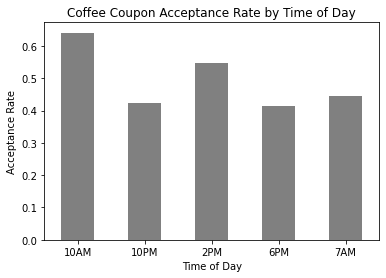

=== Insights ===

- Acceptance rates vary across different times of the day.
- Certain time periods (e.g., morning or afternoon) may show higher engagement with coffee coupons.
- Lower acceptance during late hours may indicate reduced demand or relevance.

=== What This Means ===

- Timing plays a crucial role in coupon effectiveness.
- Coffee coupons are likely more effective when aligned with typical coffee consumption times (e.g., morning).
- Businesses can optimize campaigns by targeting high-performing time slots.

=== Key Takeaway ===

Coffee coupon acceptance is influenced by time of day, suggesting that well-timed promotions can significantly improve engagement.

10AM shows the highest acceptance


In [87]:
import matplotlib.pyplot as plt

print("=== Bar Plot: Coffee Coupon Acceptance by Time of Day ===\n")
print("This plot shows how coupon acceptance varies across different times of the day.\n")

# Create bar plot
coffee_data.groupby('time')['Y'].mean().plot(kind='bar', color='grey')

# Labels and title
plt.title("Coffee Coupon Acceptance Rate by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Acceptance Rate")

plt.xticks(rotation=0)

plt.show()


print("=== Insights ===\n")

print("- Acceptance rates vary across different times of the day.")
print("- Certain time periods (e.g., morning or afternoon) may show higher engagement with coffee coupons.")
print("- Lower acceptance during late hours may indicate reduced demand or relevance.\n")


print("=== What This Means ===\n")

print("- Timing plays a crucial role in coupon effectiveness.")
print("- Coffee coupons are likely more effective when aligned with typical coffee consumption times (e.g., morning).")
print("- Businesses can optimize campaigns by targeting high-performing time slots.\n")


print("=== Key Takeaway ===\n")
print("Coffee coupon acceptance is influenced by time of day, suggesting that well-timed promotions can significantly improve engagement.\n")

print("10AM shows the highest acceptance")

=== Bar Plot: Coffee Coupon Acceptance by Passenger Type ===

This plot shows how coupon acceptance varies based on who the driver is traveling with.



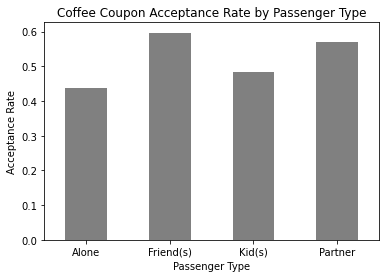

=== Insights ===

- Acceptance rates vary depending on passenger type.
- Drivers traveling alone or with friends may show higher acceptance rates.
- Drivers traveling with kids may have lower acceptance, possibly due to different priorities.

=== What This Means ===

- Social context influences coupon acceptance behavior.
- Coffee purchases may be more likely in flexible or social settings (alone, friends, partner).
- Family-related trips may reduce likelihood of stopping for coffee.

=== Key Takeaway ===

Passenger type impacts coffee coupon acceptance, with higher engagement in more flexible or social travel scenarios.



In [88]:
import matplotlib.pyplot as plt

print("=== Bar Plot: Coffee Coupon Acceptance by Passenger Type ===\n")
print("This plot shows how coupon acceptance varies based on who the driver is traveling with.\n")

# Create bar plot
coffee_data.groupby('passanger')['Y'].mean().plot(kind='bar', color='grey')

# Labels and title
plt.title("Coffee Coupon Acceptance Rate by Passenger Type")
plt.xlabel("Passenger Type")
plt.ylabel("Acceptance Rate")

plt.xticks(rotation=0)

plt.show()


print("=== Insights ===\n")

print("- Acceptance rates vary depending on passenger type.")
print("- Drivers traveling alone or with friends may show higher acceptance rates.")
print("- Drivers traveling with kids may have lower acceptance, possibly due to different priorities.\n")


print("=== What This Means ===\n")

print("- Social context influences coupon acceptance behavior.")
print("- Coffee purchases may be more likely in flexible or social settings (alone, friends, partner).")
print("- Family-related trips may reduce likelihood of stopping for coffee.\n")


print("=== Key Takeaway ===\n")
print("Passenger type impacts coffee coupon acceptance, with higher engagement in more flexible or social travel scenarios.\n")


=== Bar Plot: Coffee Coupon Acceptance by Visit Frequency ===

This plot shows how acceptance rates vary based on how often customers visit coffee houses.



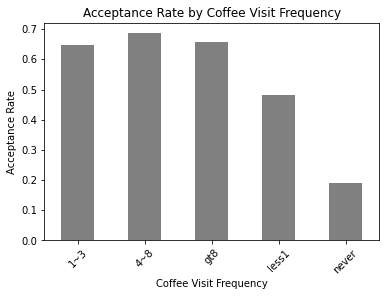

=== Insights ===

- Acceptance rate increases as coffee visit frequency increases.
- Customers who visit coffee houses frequently (e.g., 4–8 or more times) show the highest acceptance rates.
- Customers who rarely or never visit coffee houses have the lowest acceptance rates.

=== What This Means ===

- Past behavior is a strong predictor of coupon acceptance.
- Frequent coffee drinkers are more likely to respond positively to coffee-related promotions.
- Infrequent visitors may require stronger incentives to drive engagement.

=== Key Takeaway ===

Coffee coupon acceptance is strongly driven by visit frequency, highlighting the importance of behavioral targeting.



In [89]:
#Coffee Visit Frequency vs Acceptance

import matplotlib.pyplot as plt

print("=== Bar Plot: Coffee Coupon Acceptance by Visit Frequency ===\n")
print("This plot shows how acceptance rates vary based on how often customers visit coffee houses.\n")

coffee_freq = coffee_data.groupby('CoffeeHouse')['Y'].mean().sort_index()

coffee_freq.plot(kind='bar', color='grey')

plt.title("Acceptance Rate by Coffee Visit Frequency")
plt.xlabel("Coffee Visit Frequency")
plt.ylabel("Acceptance Rate")

plt.xticks(rotation=45)
plt.show()


print("=== Insights ===\n")

print("- Acceptance rate increases as coffee visit frequency increases.")
print("- Customers who visit coffee houses frequently (e.g., 4–8 or more times) show the highest acceptance rates.")
print("- Customers who rarely or never visit coffee houses have the lowest acceptance rates.\n")


print("=== What This Means ===\n")

print("- Past behavior is a strong predictor of coupon acceptance.")
print("- Frequent coffee drinkers are more likely to respond positively to coffee-related promotions.")
print("- Infrequent visitors may require stronger incentives to drive engagement.\n")


print("=== Key Takeaway ===\n")
print("Coffee coupon acceptance is strongly driven by visit frequency, highlighting the importance of behavioral targeting.\n")

In [92]:
###Hypothesis 

print("=== Final Hypothesis: Coffee Coupon Acceptance ===\n")

print("- Customers who are frequent coffee house visitors are significantly more likely to accept coffee coupons.")
print("- Acceptance behavior is strongly influenced by routine habits and existing consumption patterns.")
print("- Social context (e.g., traveling alone or with friends) and timing (e.g., morning hours) further increase likelihood of acceptance.\n")

print("=== Overall Hypothesis ===\n")
print("Coffee coupon acceptance is primarily driven by habitual behavior, where frequent coffee consumers in flexible and routine-driven contexts (such as morning commutes or social settings) are the most responsive to promotions.\n")

- Customers who are frequent coffee house visitors are significantly more likely to accept coffee coupons.
- Acceptance behavior is strongly influenced by routine habits and existing consumption patterns.
- Social context (e.g., traveling alone or with friends) and timing (e.g., morning hours) further increase likelihood of acceptance.

=== Overall Hypothesis ===

Coffee coupon acceptance is primarily driven by habitual behavior, where frequent coffee consumers in flexible and routine-driven contexts (such as morning commutes or social settings) are the most responsive to promotions.

